In [35]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df  = pd.read_csv('train.csv',usecols=['Age','Fare','Survived']) 

In [37]:
x = df.drop(columns=['Survived'])
y = df['Survived']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [38]:
# set a fixed random seed
np.random.seed(42)

In [39]:
# Get The Non-Missing values
non_missing_values = x_train['Age'].dropna().values

In [40]:
# Get The Indices Of Missing Values
missing_indices = x_train[x_train['Age'].isnull()].index

In [41]:
# Make a new Column  for filled data
x_train['Age_imputed'] = x_train['Age'].copy()

In [42]:
# filled missing values randomly
x_train.loc[missing_indices, 'Age_imputed'] = np.random.choice(non_missing_values, size=len(missing_indices))

In [43]:
x_train.isnull().sum()

Age            148
Fare             0
Age_imputed      0
dtype: int64

In [44]:
x_train.tail()

,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,21.0
493,71.0,49.5042,71.0
527,NaN,221.7792,14.0
168,NaN,25.9250,28.0


C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_5140\3925229177.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original',hist=False)
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_5140\3925229177.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_

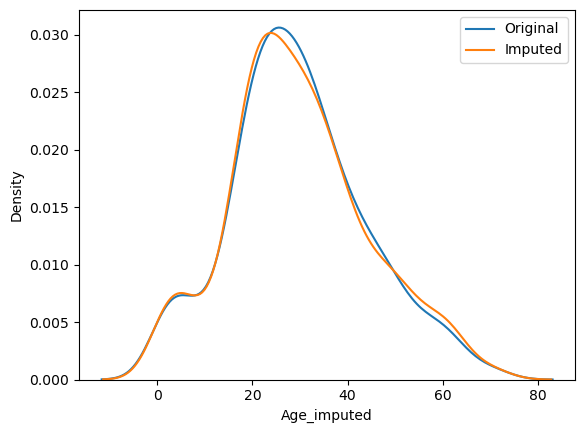

In [45]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [46]:
print('Original variable variance: ', x_train['Age'].var())
print('Variance after random imputation: ', x_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  213.4914319276537


<Axes: >

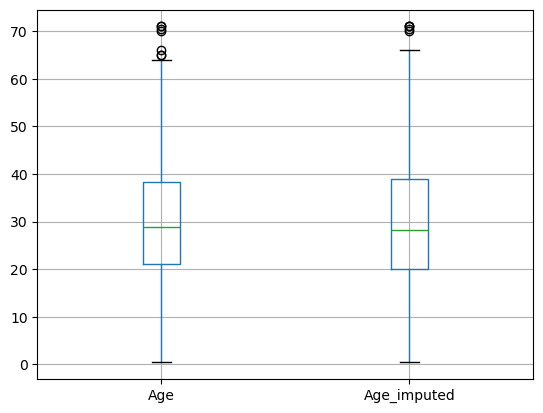

In [47]:
x_train[['Age', 'Age_imputed']].boxplot()

In [48]:
x_train.cov()

,Age,Fare,Age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,47.898304
Age_imputed,204.349513,47.898304,213.491432


In [49]:
x_train.corr()

,Age,Fare,Age_imputed
Age,1.000000,0.095814,1.000000
Fare,0.095814,1.000000,0.067362
Age_imputed,1.000000,0.067362,1.000000
